<a href="https://colab.research.google.com/github/GuilhermeHRDS/NPL/blob/main/trabalho_pln_4840505.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação de notícias com o FakeBR
**Atividade prática de PLN | Uninter | RU 4840505**

**Aluno:** Guilherme Henrique Rodrigues da Silva

Este notebook ensina a transformar textos em números, treinar um classificador e avaliar notícias que ele não viu no treinamento. Ele gera as respostas das questões REAL e FAKE e duas nuvens com pesos TF-IDF.

**Como usar:** no Google Colab, escolha **Arquivo → Fazer upload de notebook**, selecione este arquivo e execute **Ambiente de execução → Executar tudo**. Use CPU; não é necessário GPU. A primeira execução baixa o corpus e as bibliotecas.

**Resultado verificado:** 91,06% de acurácia em 1.800 notícias de teste. O resultado vale para esta divisão do FakeBR; não é uma garantia de veracidade para notícias novas.

## Objetivo e método
- Usar as 7.200 notícias originais, preservando sua correspondência por número de arquivo.
- Limpar os textos com NLTK e truncar cada par após o tratamento, para igualar exatamente a quantidade de tokens entre REAL e FAKE.
- Separar 2.700 pares para treino e 900 para teste: 75% e 25%. Um mesmo par nunca aparece nas duas partes.
- Aprender TF-IDF **somente no treino**, com unigramas, bigramas e trigramas, e treinar regressão logística.
- Contar os termos distintos efetivamente presentes em cada classe do treino e gerar nuvens ponderadas por TF-IDF.

Um **token** é um pedaço do texto, aqui uma palavra tratada. Um **bigrama** reúne dois tokens consecutivos; um **trigrama**, três. Depois da remoção de stopwords, essa vizinhança é a do texto tratado.


## 1. Preparar as bibliotecas
Uma biblioteca é uma caixa de ferramentas pronta. A NLTK trata a linguagem; o Scikit-Learn transforma os textos em números e treina o modelo; a WordCloud desenha as nuvens. As versões abaixo são as usadas na execução verificada.

In [1]:
# RU 4840505 — preparação do ambiente
import importlib.metadata as metadata
import subprocess
import sys

versoes_4840505 = {
    "nltk": "3.10.3", "scikit-learn": "1.8.0",
    "pandas": "2.2.3", "numpy": "2.3.5",
    "wordcloud": "1.9.6", "matplotlib": "3.10.8",
}
for pacote, versao in versoes_4840505.items():
    try:
        instalada = metadata.version(pacote)
    except metadata.PackageNotFoundError:
        instalada = None
    if instalada != versao:
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q",
             f"{pacote}=={versao}"], check=True,
        )
print("Bibliotecas prontas | RU 4840505")

Bibliotecas prontas | RU 4840505


## 2. Importar ferramentas e identificar o trabalho
`ru_4840505` inclui o RU no **nome da variável**, conforme o roteiro. Não usamos `nltk.download("all")`: somente as stopwords de português são necessárias.

In [ ]:
# RU 4840505 — importações e configuração
from pathlib import Path
import json
import unicodedata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from wordcloud import WordCloud
from matplotlib.colors import ListedColormap
from IPython.display import display

ru_4840505 = "4840505"
SEMENTE = 42
SAIDA = Path("resultados_4840505")
SAIDA.mkdir(exist_ok=True)
try:
    stopwords.words("portuguese")
except LookupError:
    if not nltk.download("stopwords", quiet=True):
        raise RuntimeError("Não foi possível baixar as stopwords.")
print("RU:", ru_4840505)
print(versoes_4840505)

RU: 4840505
{'nltk': '3.10.3', 'scikit-learn': '1.8.0', 'pandas': '2.2.3', 'numpy': '2.3.5', 'wordcloud': '1.9.6', 'matplotlib': '3.10.8'}


## 3. Baixar o corpus e carregar os textos
**Corpus** significa uma coleção organizada de textos. O FakeBR possui 3.600 notícias falsas e 3.600 verdadeiras. Os arquivos com o mesmo número formam um par. A lista real de arquivos é usada porque a numeração tem lacunas.

Carregamos texto e metadados em um DataFrame, uma tabela do Pandas. **Apenas o texto tratado será usado como entrada do classificador**; rótulos, links, datas e metadados não entram no TF-IDF.

Fonte: https://github.com/roneysco/Fake.br-Corpus — commit fixado para reprodução. Referência da disciplina: https://github.com/N-CPUninter/NLP.

In [ ]:
# RU 4840505 — aquisição e estruturação
REPOSITORIO = "https://github.com/roneysco/Fake.br-Corpus.git"
COMMIT = "780f5516c4ae070761632d98ac3368f3ded09d35"
PASTA = Path("Fake.br-Corpus")
if not PASTA.exists():
    subprocess.run(["git", "clone", "-q", REPOSITORIO,
                    str(PASTA)], check=True)
subprocess.run(["git", "-C", str(PASTA), "checkout", "-q",
                COMMIT], check=True)

campos_meta = """autor link categoria data tokens palavras tipos
links maiusculas verbos subjuntivos substantivos adjetivos
adverbios modais pronomes_singulares pronomes_plurais
pronomes pausality caracteres tamanho_frase tamanho_palavra
erros emotividade diversidade""".split()
registros = []
for classe, pasta in [("FAKE", "fake"), ("REAL", "true")]:
    for arquivo in (PASTA / "full_texts" / pasta).glob("*.txt"):
        par = int(arquivo.stem)
        meta = PASTA / "full_texts" / f"{pasta}-meta-information"
        valores = (meta / f"{par}-meta.txt").read_text(
            encoding="utf-8-sig").splitlines()
        assert len(valores) == len(campos_meta)
        registro = dict(zip(campos_meta, valores))
        registro.update(par=par, classe=classe, texto=arquivo.read_text(
            encoding="utf-8-sig"))
        registros.append(registro)
df = pd.DataFrame(registros).sort_values(["par", "classe"])
df = df.reset_index(drop=True)
assert len(df) == 7200 and df["texto"].notna().all()
assert not df["texto"].str.contains("\ufffd", regex=False).any()
assert df.groupby("par")["classe"].nunique().eq(2).all()
print("Notícias por classe:", df["classe"].value_counts().to_dict())
print("Amostra antes da limpeza:", df.loc[0, "texto"][:85])

Notícias por classe: {'FAKE': 3600, 'REAL': 3600}
Amostra antes da limpeza: Kátia Abreu diz que vai colocar sua expulsão em uma moldura, mas não para de reclamar


## 4. Limpar e igualar a quantidade de palavras
A limpeza deixa as entradas consistentes: minúsculas, retirada de acentos, números e pontuação, tokenização, remoção de stopwords e **stemming**. Stopwords são palavras muito comuns, como “de” e “para”. Stemming reduz palavras a radicais para agrupar variações; por isso algumas palavras nas nuvens ficam incompletas.

**Truncamento por par:** se a falsa tem 100 tokens e a verdadeira tem 400, usamos os 100 primeiros tokens de cada uma. Assim o modelo não ganha uma pista baseada no tamanho. O truncamento é feito depois da limpeza, garantindo igualdade também nos tokens efetivamente usados.

In [ ]:
# RU 4840505 — pré-processamento com NLTK
def retirar_acentos(texto):
    return "".join(c for c in unicodedata.normalize("NFD", texto)
                   if unicodedata.category(c) != "Mn")

stop_pt = {retirar_acentos(p) for p in stopwords.words("portuguese")}
stemmer = SnowballStemmer("portuguese")

def limpar(texto):
    texto = retirar_acentos(texto.lower())
    tokens = nltk.regexp_tokenize(texto, r"[a-z]+")
    return [stemmer.stem(p) for p in tokens
            if p not in stop_pt and len(p) > 1]

df["tokens"] = df["texto"].apply(limpar)
df["n_antes"] = df["tokens"].str.len()
df["n_depois"] = df.groupby("par")["n_antes"].transform("min")
df["tratado"] = [" ".join(t[:n])
                  for t, n in zip(df["tokens"], df["n_depois"])]
assert df["n_depois"].gt(0).all()
assert df.groupby("par")["n_depois"].nunique().eq(1).all()
balanco = df.groupby("classe")[["n_antes", "n_depois"]].sum()
assert balanco["n_depois"].nunique() == 1
print("Tokens após limpeza, antes e depois do truncamento:")
print(balanco)
print("Exemplo tratado:", df.loc[0, "tratado"][:85])

Tokens após limpeza, antes e depois do truncamento:
        n_antes  n_depois
classe                   
FAKE     381639    375622
REAL    2213389    375622
Exemplo tratado: kat abreu diz vai coloc expulsa moldur reclam senador kat abreu part to diss expulsa 


## 5. Separar treino e teste e calcular o TF-IDF
O **treino** são os exemplos usados para aprender. O **teste** é a prova final com exemplos separados. Mantemos cada par na mesma parte, evitando que uma notícia correspondente dê uma pista sobre a outra.

**TF-IDF** dá mais destaque a termos presentes em um texto e menos comuns na coleção de treino. `min_df=2` descarta termos presentes em apenas uma notícia; `max_df=0.95` descarta os presentes em mais de 95% das notícias de treino. `ngram_range=(1,3)` cria palavras, bigramas e trigramas. O teste recebe somente `transform`: não ensina vocabulário nem pesos ao modelo.

In [ ]:
# RU 4840505 — divisão por pares e vetorização
pares = sorted(df["par"].unique())
pares_treino, pares_teste = train_test_split(
    pares, test_size=0.25, random_state=SEMENTE)
treino = df[df["par"].isin(pares_treino)].copy()
teste = df[df["par"].isin(pares_teste)].copy()
assert set(pares_treino).isdisjoint(pares_teste)
assert not (set(treino["tratado"]) & set(teste["tratado"]))
assert len(treino) == 5400 and len(teste) == 1800

vetor = TfidfVectorizer(
    ngram_range=(1, 3), min_df=2, max_df=0.95,
    sublinear_tf=True, token_pattern=r"(?u)\b\w+\b")
X_treino = vetor.fit_transform(treino["tratado"])
X_teste = vetor.transform(teste["tratado"])
y_treino = treino["classe"].to_numpy()
y_teste = teste["classe"].to_numpy()
print("Treino:", treino["classe"].value_counts().to_dict())
print("Teste:", teste["classe"].value_counts().to_dict())
print("Vocabulário do modelo:", X_treino.shape[1], "termos")

Treino: {'FAKE': 2700, 'REAL': 2700}
Teste: {'FAKE': 900, 'REAL': 900}
Vocabulário do modelo: 94897 termos


## 6. Treinar o modelo e medir os acertos
A **regressão logística** aprende como os termos se relacionam com os rótulos REAL e FAKE. Apesar do nome “regressão”, aqui ela faz classificação.

**Acurácia** é a quantidade de acertos dividida pelo total de exemplos de teste. O hiperparâmetro `C=5` foi definido antes da avaliação deste modelo; o teste não foi usado para escolher configurações. `predict_proba` mostra probabilidades do modelo, que não devem ser interpretadas como verificação factual.

In [ ]:
# RU 4840505 — treinamento e avaliação
modelo = LogisticRegression(
    C=5.0, solver="lbfgs", max_iter=1000, random_state=SEMENTE)
modelo.fit(X_treino, y_treino)
probabilidades = modelo.predict_proba(X_teste)
predicoes = modelo.classes_[probabilidades.argmax(axis=1)]
acuracia = accuracy_score(y_teste, predicoes)
acertos = int((predicoes == y_teste).sum())
matriz = confusion_matrix(y_teste, predicoes, labels=["FAKE", "REAL"])
assert acertos / len(y_teste) == acuracia
assert acuracia > 0.85, "Rever o modelo: acurácia abaixo da meta."
print(f"RU {ru_4840505} | ACURÁCIA: {acuracia:.2%}")
print(f"Acertos: {acertos} de {len(y_teste)} notícias")
print("Matriz: linhas = classe real; colunas = classe prevista")
print(pd.DataFrame(matriz, index=["FAKE", "REAL"],
                   columns=["FAKE", "REAL"]))

RU 4840505 | ACURÁCIA: 91.06%
Acertos: 1639 de 1800 notícias
Matriz: linhas = classe real; colunas = classe prevista
      FAKE  REAL
FAKE   819    81
REAL    80   820


## 7. Contar termos e preparar as nuvens
Contamos **termos distintos do vocabulário do modelo** que têm TF-IDF maior que zero nas notícias de cada classe do treino. Isso não é o total de ocorrências de palavras. Um termo pode aparecer nas duas classes, então as contagens não devem ser somadas para obter o vocabulário geral.

Para cada nuvem, somamos os pesos TF-IDF nas notícias de treino da classe. Não usamos frequências brutas. A nuvem mostra os 100 termos com maior peso; o cálculo de contagem considera todos os termos. Tamanho na nuvem mostra relevância TF-IDF agregada, não uma prova de que aquele termo determina a veracidade.

In [ ]:
# RU 4840505 — contagens e pesos do treino
termos = vetor.get_feature_names_out()
ordem = np.array([len(t.split()) for t in termos])
pesos_por_classe = {}
contagens = {}
for classe in ["REAL", "FAKE"]:
    pesos = np.asarray(X_treino[y_treino == classe].sum(axis=0)).ravel()
    presentes = pesos > 0
    contagens[classe] = {
        "unigramas": int((presentes & (ordem == 1)).sum()),
        "bigramas": int((presentes & (ordem == 2)).sum()),
        "trigramas": int((presentes & (ordem == 3)).sum()),
    }
    pesos_por_classe[classe] = {
        termo: float(peso) for termo, peso in zip(termos, pesos)
        if peso > 0
    }
print("RU", ru_4840505, "| Termos distintos presentes no treino:")
print(pd.DataFrame(contagens).T)
print("Os termos são radicais após stemming.")

RU 4840505 | Termos distintos presentes no treino:
      unigramas  bigramas  trigramas
REAL      10258     44241      15424
FAKE      10305     46713      15785
Os termos são radicais após stemming.


In [ ]:
# RU 4840505 — função de visualização TF-IDF
def gerar_nuvem(classe, cor):
    nuvem = WordCloud(
        width=1600, height=800, background_color="white",
        max_words=100, collocations=False, prefer_horizontal=1,
        random_state=SEMENTE, colormap=ListedColormap(
            plt.get_cmap(cor)(np.linspace(0.55, 0.95, 128))),
    ).generate_from_frequencies(pesos_por_classe[classe])
    fig, ax = plt.subplots(figsize=(14, 8))
    ax.imshow(nuvem, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{classe} | Termos do treino ponderados por TF-IDF",
                 fontsize=18, pad=18)
    fig.text(0.5, 0.06, f"RU {ru_4840505} | 100 maiores pesos | Stemming",
             ha="center", fontsize=14)
    fig.tight_layout(rect=(0, 0.10, 1, 0.97))
    fig.savefig(SAIDA / f"nuvem_{classe.lower()}_4840505.png",
                dpi=160, bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

## 8. Questão 1 — notícias verdadeiras
Os números abaixo respondem quantas palavras, bigramas e trigramas foram usados dos textos REAL e qual foi a acurácia. “Palavras” significa unigramas distintos presentes no vocabulário aprendido no treino.

QUESTÃO 1 | REAL | RU 4840505
Termos distintos: {'unigramas': 10258, 'bigramas': 44241, 'trigramas': 15424}
Acurácia no teste: 91.06%


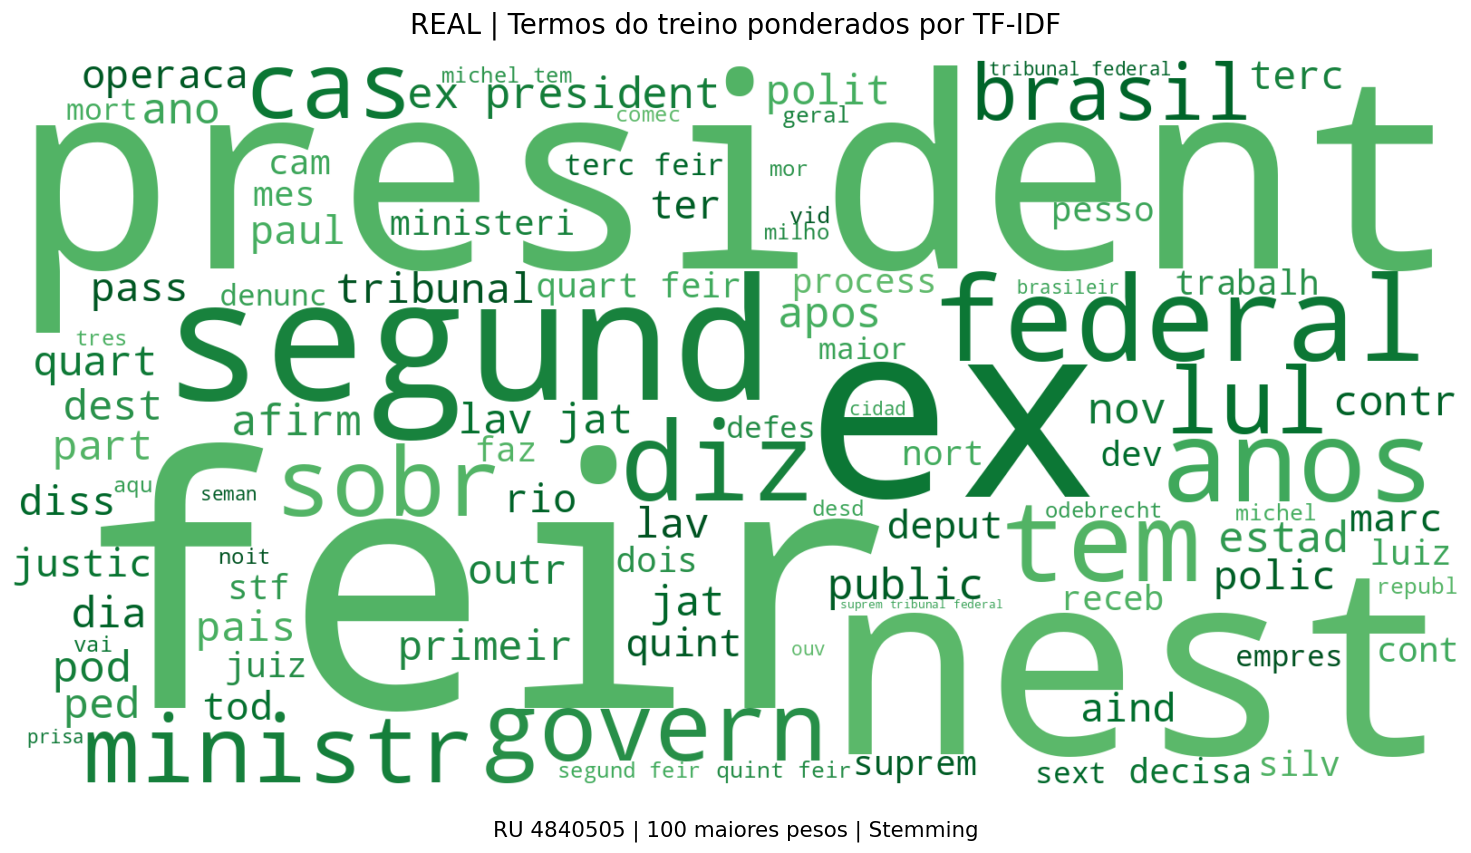

In [ ]:
# RU 4840505 — resposta e nuvem da questão 1
print("QUESTÃO 1 | REAL | RU", ru_4840505)
print("Termos distintos:", contagens["REAL"])
print(f"Acurácia no teste: {acuracia:.2%}")
gerar_nuvem("REAL", "Greens")

## 9. Questão 2 — notícias falsas
Além das contagens FAKE, a resposta descreve o pré-processamento e o modelo escolhido.

QUESTÃO 2 | FAKE | RU 4840505
Termos distintos: {'unigramas': 10305, 'bigramas': 46713, 'trigramas': 15785}
Limpeza: UTF-8, minúsculas, retirada de acentos, números
e pontuação; NLTK para tokens, stopwords e stemming;
truncamento por par; TF-IDF com n-gramas de 1 a 3.
Modelo: regressão logística, solver lbfgs, C=5.


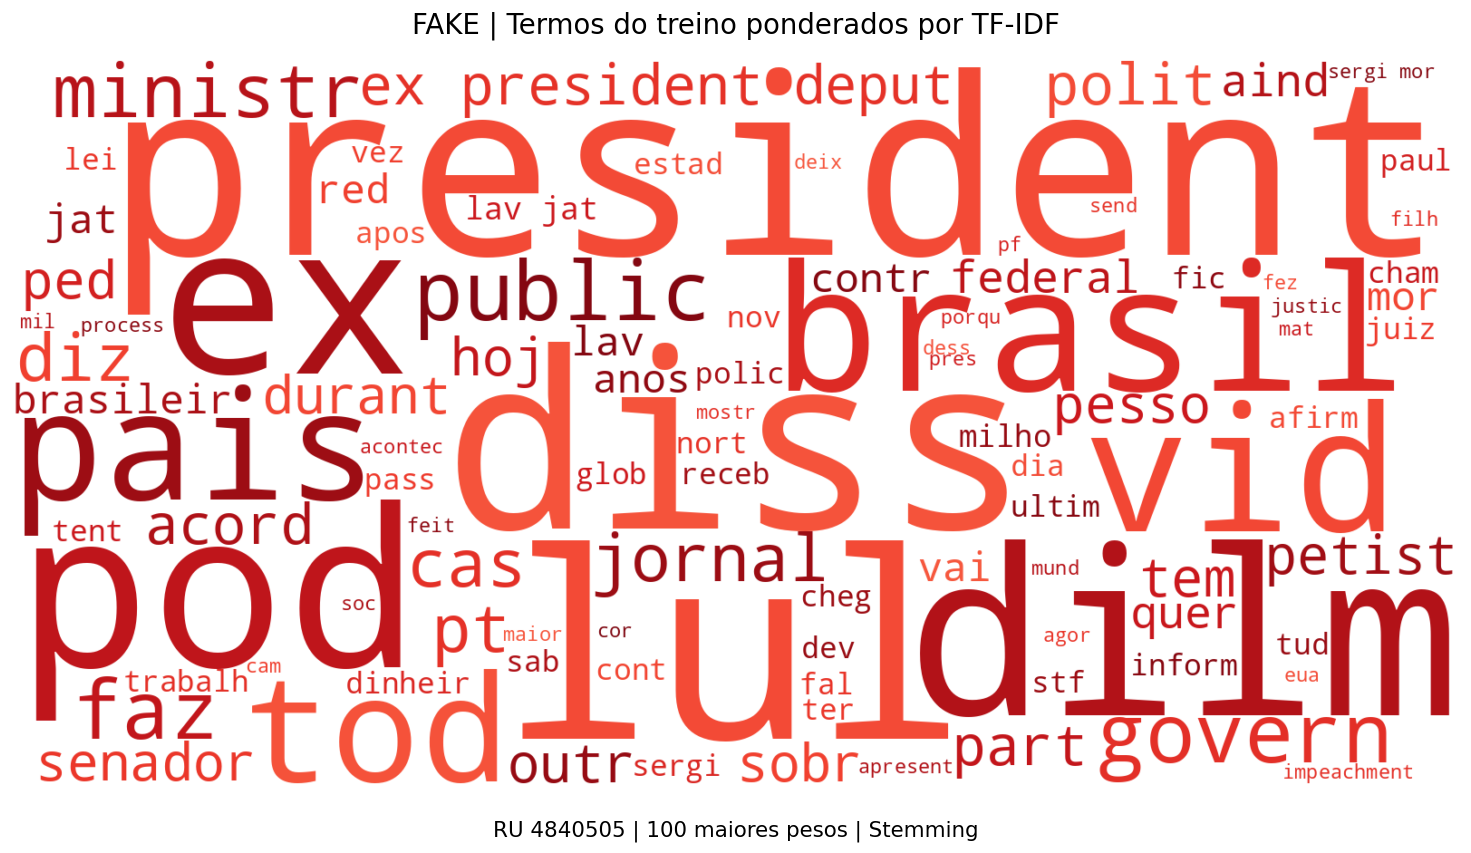

In [ ]:
# RU 4840505 — resposta e nuvem da questão 2
print("QUESTÃO 2 | FAKE | RU", ru_4840505)
print("Termos distintos:", contagens["FAKE"])
print("Limpeza: UTF-8, minúsculas, retirada de acentos, números")
print("e pontuação; NLTK para tokens, stopwords e stemming;")
print("truncamento por par; TF-IDF com n-gramas de 1 a 3.")
print("Modelo: regressão logística, solver lbfgs, C=5.")
gerar_nuvem("FAKE", "Reds")

## 10. Guardar resultados e conferir a reprodução
Este arquivo JSON registra os números da execução. O CSV registra os identificadores e tamanhos de cada notícia para conferir o balanceamento; não inclui conteúdo completo nem metadados que poderiam entrar por engano no modelo.

In [ ]:
# RU 4840505 — registro dos resultados reais
resumo = {
    "ru": ru_4840505, "commit_corpus": COMMIT,
    "acuracia": float(acuracia), "acertos": acertos,
    "n_treino": len(treino), "n_teste": len(teste),
    "vocabulario": len(termos), "contagens": contagens,
    "tokens_por_classe": balanco.to_dict(orient="index"),
    "matriz_confusao_fake_real": matriz.tolist(),
    "versoes": versoes_4840505,
}
(SAIDA / "resultados_4840505.json").write_text(
    json.dumps(resumo, ensure_ascii=False, indent=2), encoding="utf-8")
df[["par", "classe", "n_antes", "n_depois"]].to_csv(
    SAIDA / "auditoria_tamanhos_4840505.csv", index=False)
print("Execução concluída | RU", ru_4840505)
print("Arquivos gerados em:", SAIDA.resolve())

Execução concluída | RU 4840505
Arquivos gerados em: /workspace/scratch/7c92b27d98e5/trabalho_pln_4840505/resultados_4840505


## O que vale levar para o dia a dia
**Transformar texto em dados:** o mesmo processo ajuda a organizar mensagens de clientes, classificar chamados e separar assuntos de comentários. Troque as notícias por exemplos do seu problema e os rótulos por suas categorias.

**Separar treino e teste:** avaliar exemplos já usados para aprender pode criar uma impressão falsa de qualidade. Por isso a “prova” do modelo deve ficar separada.

**Cuidar das pistas enganosas:** neste exercício, notícias verdadeiras eram mais longas. Em outros projetos, a pista pode ser o nome do arquivo, um link ou um campo que revela a resposta. Aqui só o texto tratado entra no modelo.

**Interpretar os resultados:** 91,06% significa aproximadamente 91 acertos em cada 100 notícias deste teste. O modelo reconhece padrões do FakeBR, não consulta fatos nem fontes externas. Verificar uma notícia de verdade exige analisar a origem e buscar evidências.

**Ler as nuvens:** radicais como `brasil`, `polit` e `president` podem aparecer incompletos devido ao stemming. Um termo compartilhado pelas classes não deve ser tomado como um sinal automático de falsidade.

## Referências
- Roteiro e caderno de resolução da atividade prática de NLP, Uninter, 2025, fornecidos para esta atividade.
- Material da disciplina: https://github.com/N-CPUninter/NLP (commit `7a47f6c1ce0f4e7565756215426ad6bf9aab4e85`).
- FakeBR: https://github.com/roneysco/Fake.br-Corpus (commit indicado na seção de dados).
- Monteiro, R. A. et al. (2018). *Contributions to the Study of Fake News in Portuguese: New Corpus and Automatic Detection Results*. PROPOR 2018, LNCS 11122, pp. 324–334.
